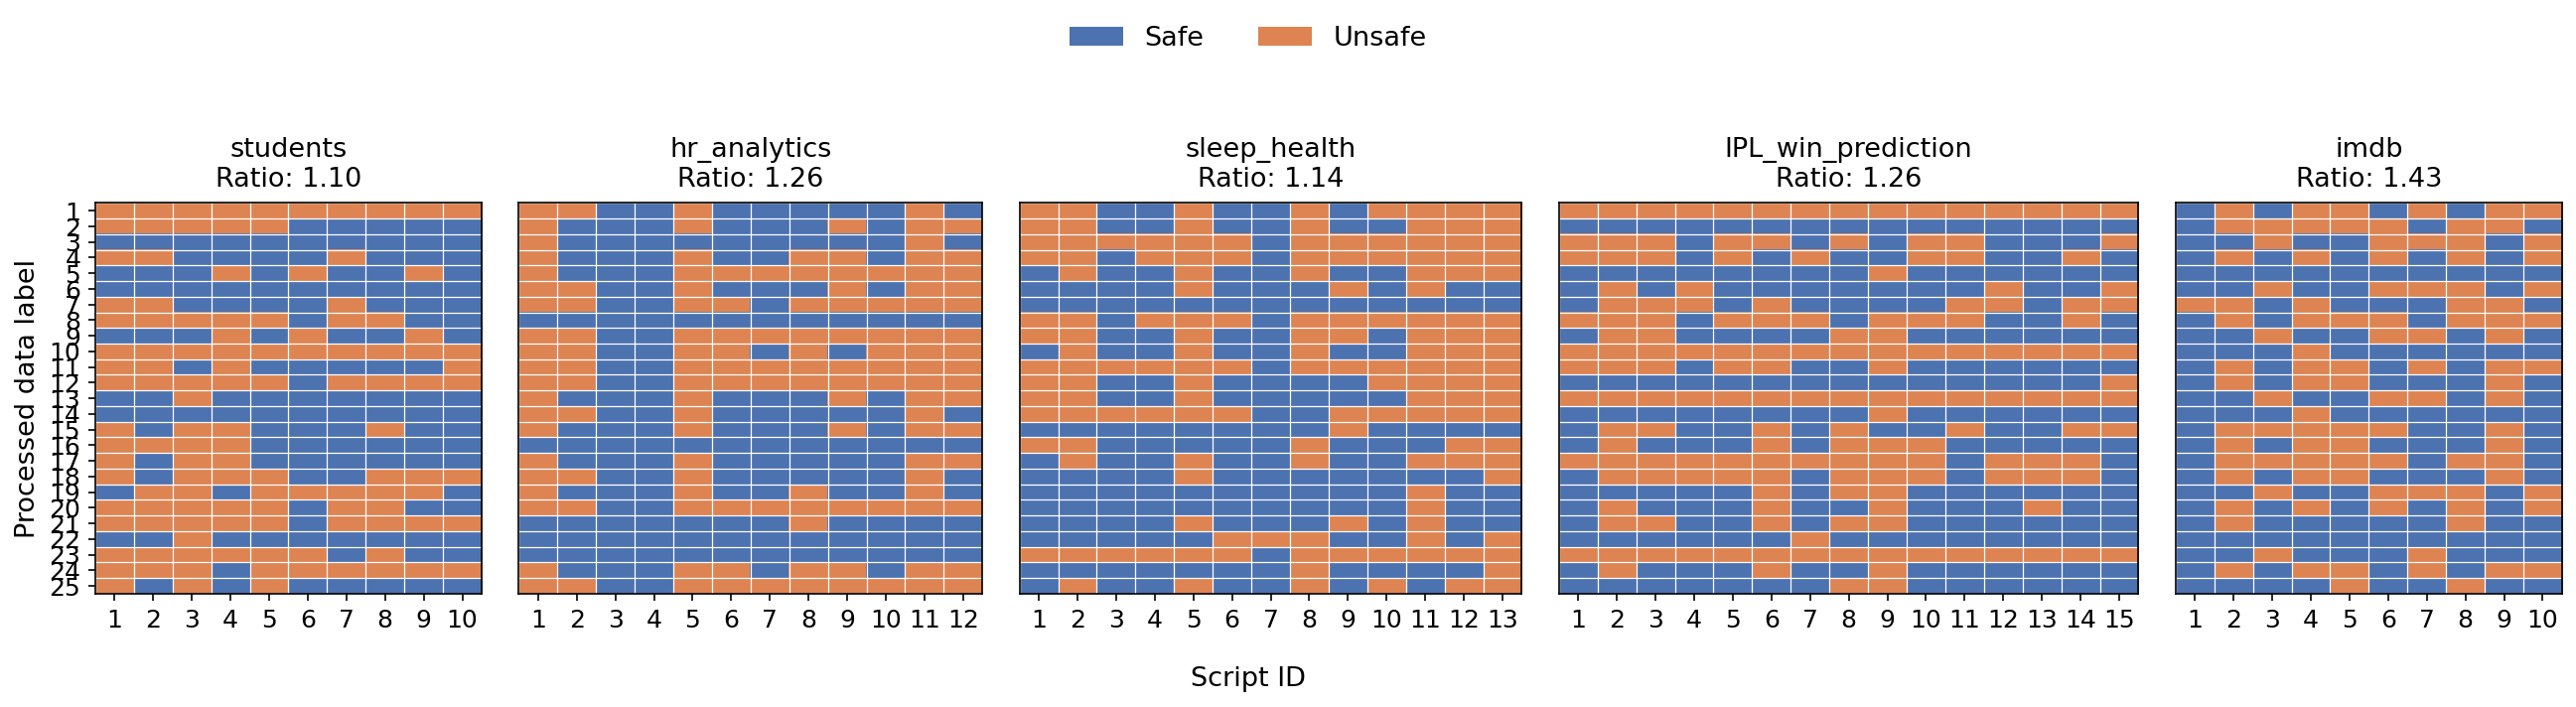

In [3]:
import oyaml as yaml
import pandas as pd

from prismadv.project_manager.manager.base import ProjectManager
from prismadv.utils import get_project_root

dataset_selections = ["students", "hr_analytics", "sleep_health","IPL_win_prediction" , "imdb"]
results_df = pd.DataFrame(columns=[
    "dataset_name", "subtask_name",
    "processed_data_label", "script_name",
    "is_safe"
])
for dataset_name in dataset_selections:
    project_manager = ProjectManager(project_root=get_project_root(), dataset_name=dataset_name)
    subtask_names = project_manager.get_available_subtasks()
    for subtask_name in subtask_names:
        processed_data_labels = project_manager.get_available_processed_data_labels_for_subtask(subtask_name)
        script_path_list = project_manager.get_available_script_path_list_for_subtask(subtask_name)
        script_names = [script_path.stem for script_path in script_path_list]
        for processed_data_label in processed_data_labels:
            if int(processed_data_label) == 0:
                continue
            for script_name in script_names:
                execution_result_path = project_manager.get_execution_output_validation_path(
                    subtask_name, processed_data_label, script_name
                ) / f"basic_metrics_evaluation.json"
                try:
                    with open(execution_result_path, "r") as f:
                        execution_results = yaml.load(f, Loader=yaml.FullLoader)
                except FileNotFoundError:
                    continue
                is_safe = execution_results['corrupted_data_is_safe']
                new_row = {
                    "dataset_name": dataset_name,
                    "subtask_name": subtask_name,
                    "processed_data_label": processed_data_label,
                    "script_name": script_name,
                    "is_safe": is_safe
                }
                results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 150,
})

n_datasets = len(dataset_selections)

dims = {}
for ds in dataset_selections:
    sdf = results_df.loc[results_df["dataset_name"] == ds]
    n_rows = sdf["processed_data_label"].nunique()
    n_cols = sdf["script_name"].nunique()
    dims[ds] = (n_rows, n_cols)

max_rows = max(r for r, c in dims.values())
width_ratios = [dims[ds][1] for ds in dataset_selections]  # proportional to #cols

cell_width = 0.30   # horizontal size of one script column
cell_height = 0.1  # vertical size of one processed_data_label row

fig_width = cell_width * sum(width_ratios)
fig_height = cell_height * max_rows + 1.6   # extra for titles / legend / xlabel

fig, axes = plt.subplots(
    1,
    n_datasets,
    figsize=(fig_width, fig_height),
    sharey=True,
    gridspec_kw={"width_ratios": width_ratios},
)

if n_datasets == 1:
    axes = [axes]

cmap = ListedColormap(["#cfcfcf", "#dd8452", "#4c72b0"])
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)


for idx, (ax, dataset_name) in enumerate(zip(axes, dataset_selections)):
    df = results_df.loc[results_df["dataset_name"] == dataset_name].copy()

    # Robust boolean normalization
    df["is_safe"] = df["is_safe"].replace(
        {"True": True, "False": False, "0": False, "1": True}
    )
    df["is_safe"] = df["is_safe"].astype("boolean")

    safe_count = int(df["is_safe"].sum(skipna=True))
    unsafe_count = int((~df["is_safe"]).sum(skipna=True))
    ratio_text = (
        f"Ratio: {safe_count/unsafe_count:.2f}"
        if unsafe_count > 0
        else f"Safe: {safe_count}, Unsafe: {unsafe_count}, All safe"
    )

    # Axis values
    x_vals = sorted(df["script_name"].astype(str).unique().tolist())
    try:
        y_vals = sorted(df["processed_data_label"].unique(), key=lambda v: int(str(v)))
    except Exception:
        y_vals = sorted(df["processed_data_label"].astype(str).unique())

    # Map script_name -> Script ID
    script_id_map = {name: i + 1 for i, name in enumerate(x_vals)}

    # -1 = missing, 0 = unsafe, 1 = safe
    df["_safe_val"] = df["is_safe"].map({True: 1, False: 0}).fillna(-1).astype(int)

    grid = (
        df.pivot_table(
            index="processed_data_label",
            columns="script_name",
            values="_safe_val",
            aggfunc="max",
        )
        .reindex(index=y_vals, columns=x_vals)
        .fillna(-1)
        .to_numpy()
    )

    im = ax.imshow(grid, cmap=cmap, norm=norm, interpolation="none", aspect="auto")

    # Gridlines
    ax.set_xticks(np.arange(len(x_vals)) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(y_vals)) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linewidth=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Tick labels
    ax.set_xticks(np.arange(len(x_vals)))
    ax.set_xticklabels([script_id_map[x] for x in x_vals])
    ax.set_yticks(np.arange(len(y_vals)))
    ax.set_yticklabels([str(v) for v in y_vals])

    # Only first subplot has y-label; others hide y-axis label
    if idx == 0:
        ax.set_ylabel("Processed data label")
    else:
        ax.set_ylabel("")
        ax.tick_params(left=False)

    # Title with counts and ratio
    ax.set_title(f"{dataset_name}\n{ratio_text}", pad=8)

handles = [
    Patch(facecolor="#4c72b0", label="Safe"),
    Patch(facecolor="#dd8452", label="Unsafe"),
]
fig.legend(
    handles=handles,
    labels=["Safe", "Unsafe"],
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.15),
)

# Single shared x label
fig.text(0.5, 0.04, "Script ID", ha="center", va="center", fontsize=13)

# Tighter layout: reduce gaps between plots
fig.subplots_adjust(
    top=0.82,
    bottom=0.18,
    left=0.07,
    right=0.99,
    wspace=0.08,   # smaller -> less horizontal gap between subplots
)

plt.show()
# save as pdf
fig.savefig("injected_error_distribution.pdf", bbox_inches="tight")